[![GitHub](https://img.shields.io/badge/GitHub-Repositorio-181717?logo=github)](https://github.com/josemarcellolopes/PI2601)


# Projeto Integrador - Ciencia de Dados aplicado a Situacoes de Mercado

**Curso:** SENAC - SUPERIOR DE TECNOLOGIA EM BANCO DE DADOS

**Entrega:** Analise exploratoria com Pandas/NumPy e 5 visualizacoes com Matplotlib

**Integrantes:**

- BRUNO DOS SANTOS GUTERRES
- EDEN FERREIRA CARDOSO
- JOSÉ MARCELLO LOPES DE OLIVEIRA
- LUCAS DE CARVALHO FERREIRA
- RAUSTHER JOSE DE SOUZA
- RENATA MIEKO SABO INOUE
- SAVIO ANTONIO PEREIRA
- VITOR HAAG PEZZINI
- YAN SAVIO SANTOS DE MORAIS FONTES

## Objetivo
Realizar uma analise exploratoria de um conjunto de dados de vendas de supermercado, gerando indicadores e visualizacoes que apoiem a tomada de decisao comercial.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [3]:
df = pd.read_csv('dataset_vendas_supermercado.csv', parse_dates=['data'])
df.head()

,id_venda,data,regiao,categoria,produto,quantidade,preco_unitario,faturamento,custo,margem,canal,pagamento
0,1,2024-11-23,Norte,Limpeza,Sabao em Po,4,15.64,62.56,37.57,24.99,Delivery,Pix
1,2,2024-10-29,Centro-Oeste,Alimentos,Feijao,4,8.68,34.72,20.32,14.40,Loja Fisica,Pix
2,3,2024-10-06,Centro-Oeste,Bebidas,Agua,1,2.68,2.68,1.64,1.04,Loja Fisica,Cartao
3,4,2024-04-20,Sul,Bebidas,Refrigerante,7,7.05,49.35,36.99,12.36,Loja Fisica,Dinheiro
4,5,2024-08-23,Sudeste,Utilidades,Pano Multiuso,2,6.90,13.80,10.29,3.51,Loja Fisica,Dinheiro


In [4]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venda        1200 non-null   int64         
 1   data            1200 non-null   datetime64[ns]
 2   regiao          1200 non-null   object        
 3   categoria       1200 non-null   object        
 4   produto         1200 non-null   object        
 5   quantidade      1200 non-null   int64         
 6   preco_unitario  1200 non-null   float64       
 7   faturamento     1200 non-null   float64       
 8   custo           1200 non-null   float64       
 9   margem          1200 non-null   float64       
 10  canal           1200 non-null   object        
 11  pagamento       1200 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 112.6+ KB


,0
id_venda,0
data,0
regiao,0
categoria,0
produto,0
quantidade,0
preco_unitario,0
faturamento,0
custo,0
margem,0


In [6]:
df.describe()

,id_venda,data,quantidade,preco_unitario,faturamento,custo,margem
count,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,2024-07-06 11:12:00,6.599167,9.253358,60.361100,41.065533,19.295567
min,1.000000,2024-01-03 00:00:00,1.000000,2.050000,2.220000,1.480000,0.620000
25%,300.750000,2024-04-05 18:00:00,4.000000,5.187500,21.660000,14.537500,6.875000
50%,600.500000,2024-07-08 12:00:00,7.000000,7.150000,44.975000,29.860000,13.720000
75%,900.250000,2024-10-05 00:00:00,10.000000,11.610000,78.872500,52.857500,24.780000
max,1200.000000,2024-12-30 00:00:00,12.000000,27.820000,330.480000,237.800000,122.000000
std,346.554469,NaN,3.538210,6.244205,55.588963,38.049078,18.377562


In [7]:
faturamento_total = df['faturamento'].sum()
margem_total = df['margem'].sum()
ticket_medio = df['faturamento'].mean()

print(f'Faturamento total: R$ {faturamento_total:,.2f}')
print(f'Margem total: R$ {margem_total:,.2f}')
print(f'Ticket medio: R$ {ticket_medio:,.2f}')

Faturamento total: R$ 72,433.32
Margem total: R$ 23,154.68
Ticket medio: R$ 60.36


## Visualizacao 1 - Faturamento por categoria

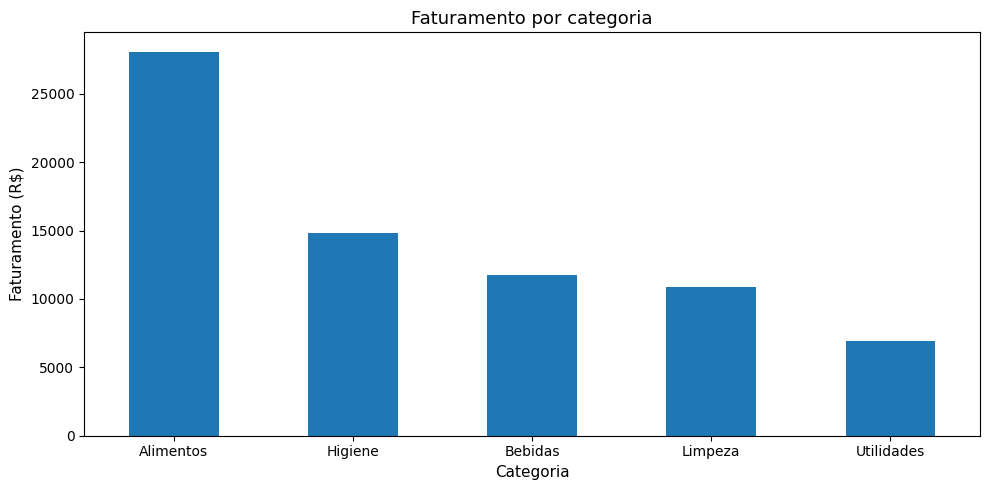

In [8]:
cat = df.groupby('categoria')['faturamento'].sum().sort_values(ascending=False)
cat.plot(kind='bar')
plt.title('Faturamento por categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretacao:** evidencia quais linhas de produtos geram mais receita e devem receber prioridade em promocao, estoque e negociacao com fornecedores.

## Visualizacao 2 - Faturamento por regiao

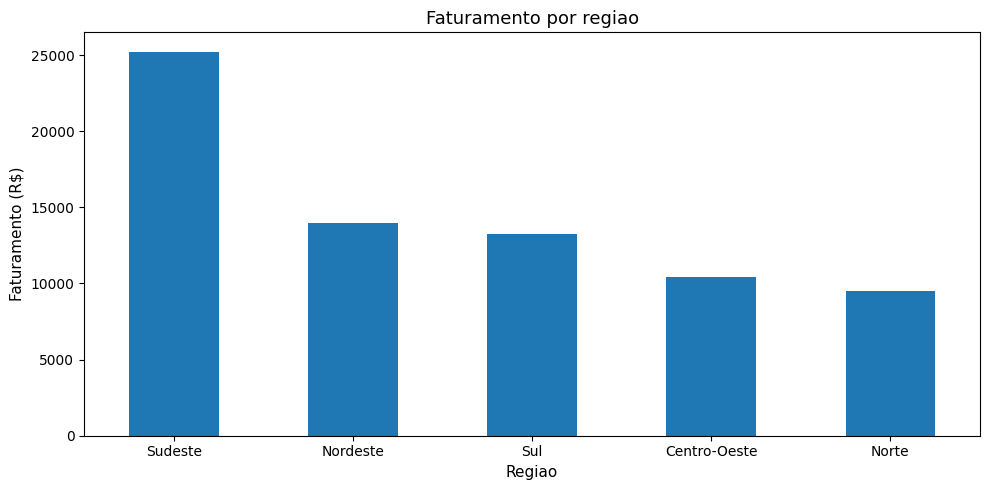

In [9]:
reg = df.groupby('regiao')['faturamento'].sum().sort_values(ascending=False)
reg.plot(kind='bar')
plt.title('Faturamento por regiao')
plt.xlabel('Regiao')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretacao:** permite comparar desempenho geografico e identificar regioes com potencial para campanhas comerciais ou revisao de mix.

## Visualizacao 3 - Evolucao mensal do faturamento

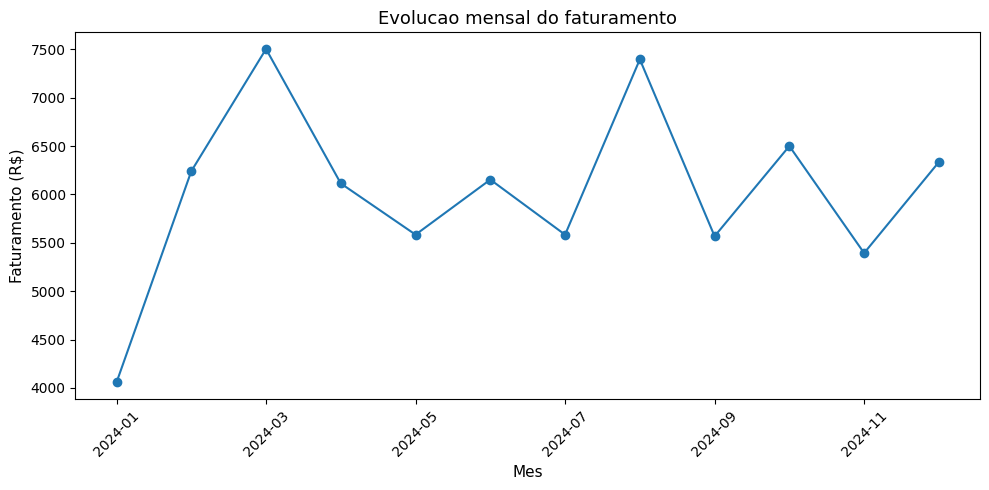

In [10]:
df['mes'] = df['data'].dt.to_period('M').astype(str)
mensal = df.groupby('mes')['faturamento'].sum()
mensal.plot(kind='line', marker='o')
plt.title('Evolucao mensal do faturamento')
plt.xlabel('Mes')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretacao:** mostra sazonalidade de vendas, facilitando a definicao de metas mensais, compras e planejamento de marketing.

## Visualizacao 4 - Distribuicao do valor das vendas

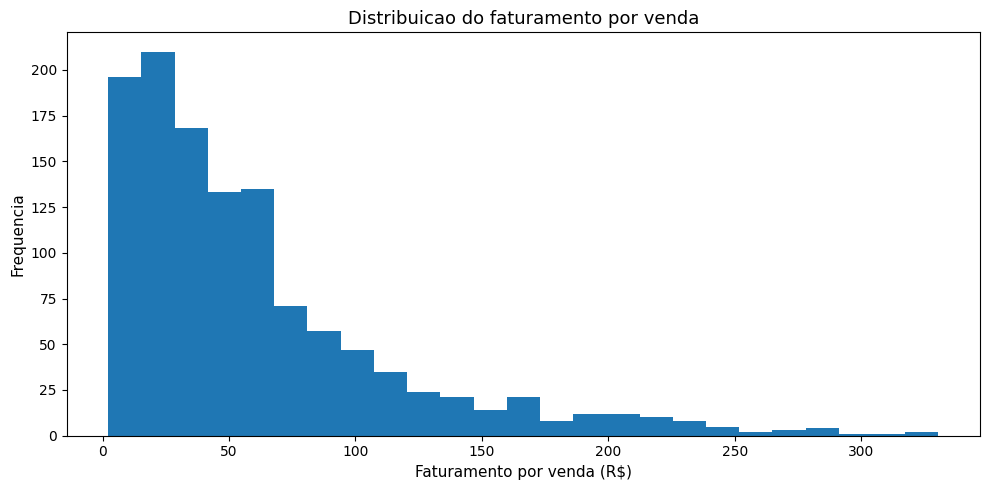

In [11]:
df['faturamento'].plot(kind='hist', bins=25)
plt.title('Distribuicao do faturamento por venda')
plt.xlabel('Faturamento por venda (R$)')
plt.ylabel('Frequencia')
plt.tight_layout()
plt.show()

**Interpretacao:** ajuda a entender o comportamento das transacoes e a diferenciar vendas de baixo, medio e alto valor.

## Visualizacao 5 - Top 10 produtos por quantidade vendida

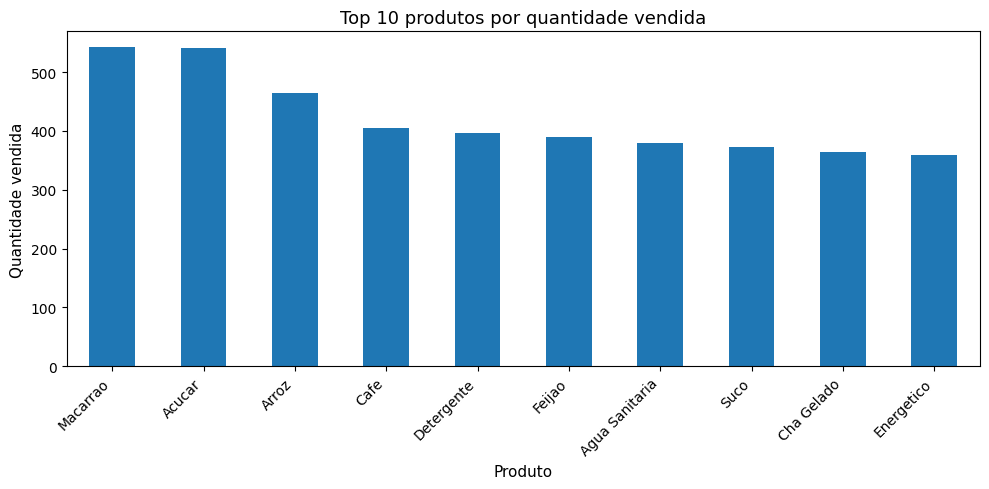

In [12]:
top_prod = df.groupby('produto')['quantidade'].sum().sort_values(ascending=False).head(10)
top_prod.plot(kind='bar')
plt.title('Top 10 produtos por quantidade vendida')
plt.xlabel('Produto')
plt.ylabel('Quantidade vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretacao:** apoia decisoes de reposicao de estoque, destaque de produtos e planejamento de compras.

## Conclusao
A analise exploratoria mostrou como dados de vendas podem ser transformados em informacoes de negocio. As visualizacoes ajudam a priorizar categorias, comparar regioes, entender sazonalidade, analisar perfil das vendas e identificar os itens mais relevantes para a operacao.